# E-waste Battery — 8-Model Evaluation (Simplified)

Outputs:
1. **9-metric comparison table** — one row per model
2. **3 × 3 qualitative figure** — input image + all 8 model predictions

Models evaluated:
1. YOLOv5n-seg  
2. YOLOv7-seg / YOLOv7-tiny-seg  
3. YOLOv8n-seg  
4. YOLO11n-seg  
5. YOLO26n-seg  
6. Mask R-CNN R50-FPN  
7. PointRend Mask R-CNN  
8. RTMDet-Ins tiny

In [1]:
# ── 0. GPU check ──────────────────────────────────────────────────────────────
import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [2]:
# ── 1. Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── 2. Global paths (edit PROJECT_ROOT only if needed) ───────────────────────
import os, sys, re, json, time, math, shutil, subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

PROJECT_ROOT  = Path("/content/drive/MyDrive/E-waste Battery Extraction CV")
DATASET_ROOT  = PROJECT_ROOT / "final_dataset"

IMG_EXTS      = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CLASS_NAMES   = ["battery"]
NUM_CLASSES   = 1
IMG_SIZE      = 640
CONF_THRES    = 0.25

YOLO_OUT      = PROJECT_ROOT / "01_yolo_models"
D2_OUT        = PROJECT_ROOT / "02_detectron2_models"
RTMDET_ROOT   = PROJECT_ROOT / "03_rtmdet_models"
METRICS_OUT   = PROJECT_ROOT / "04_metrics_and_visualisations"

EVAL_OUT      = METRICS_OUT / "eight_model_eval_selected_test"
EVAL_OUT.mkdir(parents=True, exist_ok=True)

# Model weight paths
MODEL_PATHS = {
    "YOLOv5n-seg":               YOLO_OUT / "model_01_yolov5n_seg"                    / "weights" / "best.pt",
    "YOLOv7-seg / YOLOv7-tiny-seg": YOLO_OUT / "model_02_yolov7_seg"                 / "weights" / "best.pt",
    "YOLOv8n-seg":               YOLO_OUT / "model_03_yolov8n_seg"                    / "weights" / "best.pt",
    "YOLO11n-seg":               YOLO_OUT / "model_04_yolo11n_seg"                    / "weights" / "best.pt",
    "YOLO26n-seg":               YOLO_OUT / "optional_yolo26n_seg"                    / "weights" / "best.pt",
    "Mask R-CNN R50-FPN":        D2_OUT   / "model_05_mask_rcnn_R50_FPN"              / "model_final.pth",
    "PointRend Mask R-CNN":      D2_OUT   / "model_07_pointrend_mask_rcnn_R50_FPN"   / "model_final.pth",
}

RTMDET_WORK_DIR      = RTMDET_ROOT / "model_07_rtmdet_ins_tiny"
RTMDET_CUSTOM_CONFIG = RTMDET_WORK_DIR / "rtmdet_ins_tiny_battery.py"
MMDET_DIR            = Path("/content/mmdetection")
MAMBA_ROOT_PREFIX    = Path("/content/micromamba")
MAMBA_EXE            = Path("/content/micromamba-bin/micromamba")
ENV_NAME             = "rtmdet310"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT exists:", DATASET_ROOT.exists())
print("\nModel weights:")
for name, path in MODEL_PATHS.items():
    print(f"  {name:<40s}", "FOUND" if path.exists() else "MISSING")

PROJECT_ROOT: /content/drive/MyDrive/E-waste Battery Extraction CV
DATASET_ROOT exists: True

Model weights:
  YOLOv5n-seg                              FOUND
  YOLOv7-seg / YOLOv7-tiny-seg             FOUND
  YOLOv8n-seg                              FOUND
  YOLO11n-seg                              FOUND
  YOLO26n-seg                              FOUND
  Mask R-CNN R50-FPN                       FOUND
  PointRend Mask R-CNN                     FOUND


In [4]:
# ── 3. Install packages ───────────────────────────────────────────────────────
!pip install -q -U ultralytics opencv-python pycocotools pandas numpy tqdm pyyaml

import cv2
from tqdm import tqdm
print("Packages ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 83.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.5 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but

In [11]:
import yaml

EVAL_ROOT    = PROJECT_ROOT / "eval_test_subset_original_plus_selected_aug"
EVAL_IMG_DIR = EVAL_ROOT / "images" / "test"
EVAL_LBL_DIR = EVAL_ROOT / "labels" / "test"
TEST_IMG_DIR = DATASET_ROOT / "images" / "test"
TEST_LBL_DIR = DATASET_ROOT / "labels" / "test"
EVAL_DATA_YAML = PROJECT_ROOT / "data_eval_selected_test.yaml"
EVAL_IMAGES = sorted([p for p in EVAL_IMG_DIR.iterdir() if p.suffix.lower() in IMG_EXTS])

In [ ]:
# ── 4. Build fixed evaluation subset ─────────────────────────────────────────
# Rule: original image + aug_1/2/3 (if ≥4 augs exist), else all augs.
import yaml

EVAL_ROOT    = PROJECT_ROOT / "eval_test_subset_original_plus_selected_aug"
EVAL_IMG_DIR = EVAL_ROOT / "images" / "test"
EVAL_LBL_DIR = EVAL_ROOT / "labels" / "test"
TEST_IMG_DIR = DATASET_ROOT / "images" / "test"
TEST_LBL_DIR = DATASET_ROOT / "labels" / "test"
AUG_RE       = re.compile(r"^(?P<base>.+)_aug_(?P<idx>\d+)$", re.IGNORECASE)

def split_base_aug(stem):
    m = AUG_RE.match(stem)
    return (m.group("base"), int(m.group("idx"))) if m else (stem, None)

if EVAL_ROOT.exists():
    shutil.rmtree(EVAL_ROOT)
EVAL_IMG_DIR.mkdir(parents=True, exist_ok=True)
EVAL_LBL_DIR.mkdir(parents=True, exist_ok=True)

groups = defaultdict(lambda: {"original": None, "augs": {}})
for p in sorted(TEST_IMG_DIR.iterdir()):
    if p.suffix.lower() not in IMG_EXTS:
        continue
    base, idx = split_base_aug(p.stem)
    if idx is None:
        groups[base]["original"] = p
    else:
        groups[base]["augs"][idx] = p

selected, copied = [], []
for base, item in sorted(groups.items()):
    if item["original"]:
        selected.append(item["original"])
    augs = item["augs"]
    for idx in ([1, 2, 3] if len(augs) >= 4 else sorted(augs)):
        if idx in augs:
            selected.append(augs[idx])

for img in selected:
    lbl = TEST_LBL_DIR / f"{img.stem}.txt"
    if lbl.exists():
        shutil.copy2(img, EVAL_IMG_DIR / img.name)
        shutil.copy2(lbl, EVAL_LBL_DIR / lbl.name)
        copied.append(img.name)

EVAL_DATA_YAML = PROJECT_ROOT / "data_eval_selected_test.yaml"
with open(EVAL_DATA_YAML, "w") as f:
    yaml.safe_dump({"path": str(EVAL_ROOT), "train": "images/test",
                    "val": "images/test", "test": "images/test",
                    "nc": NUM_CLASSES, "names": CLASS_NAMES}, f, sort_keys=False)

EVAL_IMAGES = sorted([p for p in EVAL_IMG_DIR.iterdir() if p.suffix.lower() in IMG_EXTS])
print(f"Evaluation images: {len(EVAL_IMAGES)}")

In [6]:
EVAL_COCO_DIR = PROJECT_ROOT / "eval_coco_annotations"
EVAL_COCO_JSON = EVAL_COCO_DIR / "test_selected.json"
MMDET_ANN_DIR = DATASET_ROOT / "mmdet_annotations"

In [ ]:
# ── 5. Convert eval subset to COCO JSON (for Detectron2 / RTMDet) ─────────────
EVAL_COCO_DIR = PROJECT_ROOT / "eval_coco_annotations"
EVAL_COCO_DIR.mkdir(parents=True, exist_ok=True)
EVAL_COCO_JSON = EVAL_COCO_DIR / "test_selected.json"

images, annotations, ann_id, img_id = [], [], 1, 1

for img_path in tqdm(EVAL_IMAGES, desc="Building COCO JSON"):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]
    images.append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})

    lbl = EVAL_LBL_DIR / f"{img_path.stem}.txt"
    if lbl.exists() and lbl.read_text().strip():
        for line in lbl.read_text().strip().splitlines():
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            coords = list(map(float, parts[1:]))
            if len(coords) % 2:
                coords = coords[:-1]
            poly, xs, ys = [], [], []
            for i in range(0, len(coords), 2):
                x = max(0., min(float(w - 1), coords[i] * w))
                y = max(0., min(float(h - 1), coords[i + 1] * h))
                poly += [x, y]; xs.append(x); ys.append(y)
            if len(xs) < 3:
                continue
            bw, bh = max(xs) - min(xs), max(ys) - min(ys)
            if bw <= 1 or bh <= 1:
                continue
            area = float(abs(cv2.contourArea(np.array(poly, dtype=np.float32).reshape(-1, 2))))
            annotations.append({"id": ann_id, "image_id": img_id, "category_id": 1,
                                 "segmentation": [poly],
                                 "bbox": [float(min(xs)), float(min(ys)), bw, bh],
                                 "area": area, "iscrowd": 0})
            ann_id += 1
    img_id += 1

coco = {"images": images, "annotations": annotations,
        "categories": [{"id": 1, "name": "battery", "supercategory": "object"}]}
with open(EVAL_COCO_JSON, "w") as f:
    json.dump(coco, f)

MMDET_ANN_DIR = DATASET_ROOT / "mmdet_annotations"
MMDET_ANN_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(EVAL_COCO_JSON, MMDET_ANN_DIR / "test_selected_original_plus_aug.json")
print(f"COCO JSON: {len(images)} images, {len(annotations)} annotations")

In [7]:
# ── 6. Shared metric utilities ────────────────────────────────────────────────

def yolo_label_to_mask(label_path, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    label_path = Path(label_path)
    if not label_path.exists() or not label_path.read_text().strip():
        return mask
    for line in label_path.read_text().strip().splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        coords = list(map(float, parts[1:]))
        if len(coords) % 2:
            coords = coords[:-1]
        pts = [[int(round(coords[i]*w)), int(round(coords[i+1]*h))]
               for i in range(0, len(coords), 2)]
        if len(pts) >= 3:
            cv2.fillPoly(mask, [np.array(pts, dtype=np.int32)], 1)
    return mask

def mask_iou(pred, gt, eps=1e-7):
    p, g = pred.astype(bool), gt.astype(bool)
    inter, union = np.logical_and(p, g).sum(), np.logical_or(p, g).sum()
    return 1.0 if union == 0 and inter == 0 else float(inter / (union + eps))

def mask_centroid(mask):
    ys, xs = np.where(mask > 0)
    return (float(xs.mean()), float(ys.mean())) if len(xs) else None

def centroid_error_px(pred, gt):
    pc, gc = mask_centroid(pred), mask_centroid(gt)
    if pc is None or gc is None:
        return np.nan
    return math.sqrt((pc[0]-gc[0])**2 + (pc[1]-gc[1])**2)

def compute_task_metrics(pred_masks_by_stem, iou_thresh=0.50):
    ious, ces, tp, fp, fn = [], [], 0, 0, 0
    for img_path in EVAL_IMAGES:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        gt   = yolo_label_to_mask(EVAL_LBL_DIR / f"{img_path.stem}.txt", img.shape)
        pred = pred_masks_by_stem.get(img_path.stem, np.zeros(gt.shape, dtype=np.uint8))
        iou  = mask_iou(pred, gt)
        ious.append(iou)
        ces.append(centroid_error_px(pred, gt))
        has_gt, has_pred = gt.sum() > 0, pred.sum() > 0
        if has_pred and has_gt and iou >= iou_thresh:  tp += 1
        elif has_pred and (not has_gt or iou < iou_thresh): fp += 1
        if has_gt and (not has_pred or iou < iou_thresh):   fn += 1
    prec = tp / (tp + fp + 1e-7)
    rec  = tp / (tp + fn + 1e-7)
    return {"Precision": float(prec), "Recall": float(rec),
            "Mean Mask IoU": float(np.nanmean(ious)) if ious else np.nan,
            "Centroid Error (px)": float(np.nanmean(ces)) if ces else np.nan}

def fps_from_ms(ms):
    return 1000.0 / ms if ms and not np.isnan(ms) and ms > 0 else np.nan

def run_cmd(cmd, cwd=None):
    r = subprocess.run(cmd, shell=True, cwd=cwd, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(r.stdout)
    return r.stdout

def parse_yolo_val_output(text):
    lines = [l for l in text.splitlines()
             if re.search(r"\ball\b", l) and len(re.findall(r"[-+]?\d*\.\d+|\d+", l)) >= 10]
    if not lines:
        return {k: np.nan for k in ["Mask mAP@50", "Mask mAP@50:95"]}
    vals = [float(x) for x in re.findall(r"[-+]?\d*\.\d+|\d+", lines[-1])][-8:]
    return {"Mask mAP@50": vals[6], "Mask mAP@50:95": vals[7]}

def load_pred_masks_from_txt(label_dir):
    masks = {}
    for img_path in EVAL_IMAGES:
        img = cv2.imread(str(img_path))
        if img is not None:
            masks[img_path.stem] = yolo_label_to_mask(
                Path(label_dir) / f"{img_path.stem}.txt", img.shape)
    return masks

def count_params_pt(weights_path, repo_dir=None):
    old = os.getcwd()
    if repo_dir:
        sys.path.insert(0, str(repo_dir))
        os.chdir(str(repo_dir))
    try:
        ckpt = torch.load(str(weights_path), map_location="cpu", weights_only=False)
        model = ckpt.get("ema") or ckpt.get("model")
        return float(sum(p.numel() for p in model.parameters()) / 1e6) if model else np.nan
    except Exception as e:
        print("param count failed:", e); return np.nan
    finally:
        os.chdir(old)

# ── Evaluation accumulator ───────────────────────────────────────────────────
METRIC_COLS = ["Mask mAP@50", "Mask mAP@50:95", "Precision", "Recall",
               "Mean Mask IoU", "Latency (ms/image)", "FPS", "Parameters (M)",
               "Centroid Error (px)"]
MODEL_ORDER = ["YOLOv5n-seg", "YOLOv7-seg / YOLOv7-tiny-seg", "YOLOv8n-seg",
               "YOLO11n-seg", "YOLO26n-seg", "Mask R-CNN R50-FPN",
               "PointRend Mask R-CNN", "RTMDet-Ins tiny"]

eval_rows = []

def add_row(model_name, mask_map50=np.nan, mask_map5095=np.nan,
            precision=np.nan, recall=np.nan, mean_iou=np.nan,
            latency_ms=np.nan, params_m=np.nan, centroid_err=np.nan):
    eval_rows.append({
        "Model": model_name,
        "Mask mAP@50":       mask_map50,
        "Mask mAP@50:95":    mask_map5095,
        "Precision":         precision,
        "Recall":            recall,
        "Mean Mask IoU":     mean_iou,
        "Latency (ms/image)": latency_ms,
        "FPS":               fps_from_ms(latency_ms),
        "Parameters (M)":    params_m,
        "Centroid Error (px)": centroid_err,
    })

def get_df():
    df = pd.DataFrame(eval_rows).drop_duplicates("Model", keep="last")
    df["Model"] = pd.Categorical(df["Model"], categories=MODEL_ORDER, ordered=True)
    return df.sort_values("Model").reset_index(drop=True)

print("Utilities ready.")

Utilities ready.


In [12]:
# ── 7. Evaluate Ultralytics models (YOLOv8n, YOLO11n, YOLO26n) ───────────────
from ultralytics import YOLO

def eval_ultralytics(model_name, weights_path):
    weights_path = Path(weights_path)
    if not weights_path.exists():
        print(f"Skipping {model_name} — missing weights"); return

    print(f"\n=== {model_name} ===")
    device = 0 if torch.cuda.is_available() else "cpu"
    model  = YOLO(str(weights_path))

    metrics = model.val(data=str(EVAL_DATA_YAML), split="test", imgsz=IMG_SIZE,
                        batch=32, device=device, plots=False, verbose=False,
                        project=str(EVAL_OUT),
                        name=f"{model_name.replace(' ','_').replace('/','_')}_val",
                        exist_ok=True)

    # warm-up
    for p in EVAL_IMAGES[:3]:
        model.predict(source=str(p), imgsz=IMG_SIZE, conf=CONF_THRES,
                      device=device, verbose=False)

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    pred_masks = {}
    for p in tqdm(EVAL_IMAGES, desc=model_name):
        img = cv2.imread(str(p))
        if img is None: continue
        h, w = img.shape[:2]
        res = model.predict(source=str(p), imgsz=IMG_SIZE, conf=CONF_THRES,
                            device=device, verbose=False)[0]
        m = np.zeros((h, w), dtype=np.uint8)
        if res.masks is not None:
            for mk in res.masks.data.detach().cpu().numpy():
                mk = cv2.resize(mk, (w, h), interpolation=cv2.INTER_LINEAR)
                m  = np.maximum(m, (mk > 0.5).astype(np.uint8))
        pred_masks[p.stem] = m
    if torch.cuda.is_available(): torch.cuda.synchronize()
    lat_ms = (time.perf_counter() - t0) / max(1, len(EVAL_IMAGES)) * 1000

    tm = compute_task_metrics(pred_masks)
    add_row(model_name,
            mask_map50=float(metrics.seg.map50),
            mask_map5095=float(metrics.seg.map),
            precision=tm["Precision"], recall=tm["Recall"],
            mean_iou=tm["Mean Mask IoU"], latency_ms=lat_ms,
            params_m=sum(p.numel() for p in model.model.parameters()) / 1e6,
            centroid_err=tm["Centroid Error (px)"])

for name in ["YOLOv8n-seg", "YOLO11n-seg", "YOLO26n-seg"]:
    eval_ultralytics(name, MODEL_PATHS[name])

display(get_df())


=== YOLOv8n-seg ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 353.7±241.4 MB/s, size: 2328.3 KB)
val: Scanning /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test.cache... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 22.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8s/it 3.6s
                   all         48         48      0.999      0.979      0.975      0.913          1      0.999      0.995      0.898
Speed: 1.7ms preprocess, 3.7ms inference, 0.0ms loss, 3.4ms postprocess per image


YOLOv8n-seg: 100%|██████████| 48/48 [00:04<00:00, 11.27it/s]



=== YOLO11n-seg ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 220.2±225.8 MB/s, size: 1088.9 KB)
val: Scanning /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test.cache... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 18.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.2s
                   all         48         48      0.999          1      0.995      0.936      0.999          1      0.995      0.916
Speed: 1.0ms preprocess, 5.1ms inference, 0.0ms loss, 2.2ms postprocess per image


YOLO11n-seg: 100%|██████████| 48/48 [00:04<00:00, 11.34it/s]



=== YOLO26n-seg ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 422.1±237.5 MB/s, size: 2834.5 KB)
val: Scanning /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test.cache... 48 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 15.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 1.9s
                   all         48         48      0.923      0.998      0.991      0.916      0.923      0.998      0.991      0.916
Speed: 0.6ms preprocess, 4.4ms inference, 0.0ms loss, 1.2ms postprocess per image


YOLO26n-seg: 100%|██████████| 48/48 [00:04<00:00, 11.22it/s]


,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv8n-seg,0.995000,0.897642,1.0,1.0,0.911854,88.820657,11.258642,3.258259,26.247238
1,YOLO11n-seg,0.995000,0.915911,1.0,1.0,0.919545,88.227299,11.334360,2.834763,21.111600
2,YOLO26n-seg,0.990985,0.915873,1.0,1.0,0.920864,89.169097,11.214648,2.689079,24.203801


In [20]:
# ── 8. Evaluate YOLOv5n-seg ───────────────────────────────────────────────────
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"]     = "disabled"

YOLOV5_DIR     = Path("/content/yolov5")
YOLOV5_WEIGHTS = MODEL_PATHS["YOLOv5n-seg"]

if not YOLOV5_DIR.exists():
    !git clone -q https://github.com/ultralytics/yolov5.git "{YOLOV5_DIR}"

%cd "{YOLOV5_DIR}"
!pip -q install -r requirements.txt

if not YOLOV5_WEIGHTS.exists():
    print("Skipping YOLOv5n-seg — missing weights")
else:
    NAME = "eval_model_01_yolov5n_seg"

    val_out = run_cmd(
        f'python segment/val.py --weights "{YOLOV5_WEIGHTS}" --data "{EVAL_DATA_YAML}" '
        f'--img {IMG_SIZE} --batch 32 --task test --device 0 '
        f'--project "{EVAL_OUT}" --name "{NAME}_val" --exist-ok',
        cwd=str(YOLOV5_DIR))
    map_m = parse_yolo_val_output(val_out)

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    run_cmd(
        f'python segment/predict.py --weights "{YOLOV5_WEIGHTS}" --source "{EVAL_IMG_DIR}" '
        f'--img {IMG_SIZE} --conf {CONF_THRES} --device 0 '
        f'--save-txt --save-conf --nosave '
        f'--project "{EVAL_OUT}" --name "{NAME}_predict" --exist-ok',
        cwd=str(YOLOV5_DIR))
    if torch.cuda.is_available(): torch.cuda.synchronize()
    lat_ms = (time.perf_counter() - t0) / max(1, len(EVAL_IMAGES)) * 1000

    pred_masks = load_pred_masks_from_txt(EVAL_OUT / f"{NAME}_predict" / "labels")
    tm = compute_task_metrics(pred_masks)
    add_row("YOLOv5n-seg",
            mask_map50=map_m["Mask mAP@50"], mask_map5095=map_m["Mask mAP@50:95"],
            precision=tm["Precision"], recall=tm["Recall"],
            mean_iou=tm["Mean Mask IoU"], latency_ms=lat_ms,
            params_m=1.8847,
            centroid_err=tm["Centroid Error (px)"])

%cd /content
display(get_df())

/content/yolov5
segment/val: data=/content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml, weights=['/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_01_yolov5n_seg/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/eight_model_eval_selected_test, name=eval_model_01_yolov5n_seg_val, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 165 layers, 1879750 parameters, 0 gradients, 6.7 GFLOPs

test: Scanning /content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test...:   0%|          | 0/48 [00:00<?, ?it/s]


,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv5n-seg,0.995000,0.911000,1.000000,1.000000,0.925830,260.430688,3.839793,1.884700,34.885123
1,YOLOv7-seg / YOLOv7-tiny-seg,0.995000,0.949000,1.000000,1.000000,0.957896,501.162888,1.995359,37.866100,22.712212
2,YOLOv8n-seg,0.995000,0.897642,1.000000,1.000000,0.911854,88.820657,11.258642,3.258259,26.247238
3,YOLO11n-seg,0.995000,0.915911,1.000000,1.000000,0.919545,88.227299,11.334360,2.834763,21.111600
4,YOLO26n-seg,0.990985,0.915873,1.000000,1.000000,0.920864,89.169097,11.214648,2.689079,24.203801
5,Mask R-CNN R50-FPN,1.000000,0.786151,0.979167,0.979167,0.882035,135.153508,7.398994,43.918038,52.848001
6,PointRend Mask R-CNN,1.000000,0.794408,1.000000,1.000000,0.886069,145.238610,6.885221,55.701768,55.030060


In [21]:
# ── 9. Evaluate YOLOv7-seg ────────────────────────────────────────────────────
from pycocotools import mask as mask_utils

YOLOV7_DIR     = Path("/content/yolov7-segmentation")
YOLOV7_WEIGHTS = MODEL_PATHS["YOLOv7-seg / YOLOv7-tiny-seg"]

if not YOLOV7_DIR.exists():
    !git clone -q https://github.com/RizwanMunawar/yolov7-segmentation.git "{YOLOV7_DIR}"

%cd "{YOLOV7_DIR}"
!pip install -q filterpy   # fix #1: predict.py needs this

if not YOLOV7_WEIGHTS.exists():
    print("Skipping YOLOv7 — missing weights")
else:
    # ── Compatibility patches ─────────────────────────────────────────────────
    for script in [YOLOV7_DIR/"segment"/"val.py", YOLOV7_DIR/"segment"/"predict.py"]:
        if script.exists():
            txt = script.read_text()
            if "torch_load_compat_patch" not in txt:
                txt = txt.replace("import torch\n",
                    'import torch\n# torch_load_compat_patch\n'
                    '_orig_torch_load = torch.load\n'
                    'def _torch_load_compat(*a,**kw):\n'
                    '    kw.setdefault("weights_only",False)\n'
                    '    return _orig_torch_load(*a,**kw)\n'
                    'torch.load = _torch_load_compat\n', 1)
                script.write_text(txt)

    for fp in [
        YOLOV7_DIR/"utils"/"dataloaders.py", YOLOV7_DIR/"utils"/"general.py",
        YOLOV7_DIR/"utils"/"plots.py",       YOLOV7_DIR/"utils"/"metrics.py",
        YOLOV7_DIR/"utils"/"segment"/"dataloaders.py",
        YOLOV7_DIR/"utils"/"segment"/"plots.py",
    ]:
        if fp.exists():
            t = fp.read_text()
            for old, new in [(r"\bnp\.int\b(?!\d)","int"),(r"\bnp\.float\b(?!\d)","float"),
                             (r"\bnp\.bool\b(?!_)","bool"),("np.trapz","np.trapezoid")]:
                t = re.sub(old, new, t)
            fp.write_text(t)

    # ── fix #1 cont: patch PIL getsize (non-fatal thread error but noisy) ─────
    plots_path = YOLOV7_DIR / "utils" / "plots.py"
    if plots_path.exists():
        t = plots_path.read_text()
        t = t.replace(
            "w, h = self.font.getsize(label)",
            "w, h = (self.font.getbbox(label)[2], self.font.getbbox(label)[3]) "
            "if hasattr(self.font, 'getbbox') else self.font.getsize(label)")
        plots_path.write_text(t)

    NAME = "eval_model_02_yolov7_seg"

    # ── val.py for mAP ────────────────────────────────────────────────────────
    val_out = run_cmd(
        f'python segment/val.py --weights "{YOLOV7_WEIGHTS}" --data "{EVAL_DATA_YAML}" '
        f'--img {IMG_SIZE} --batch 32 --task test --device 0 --save-json '
        f'--project "{EVAL_OUT}" --name "{NAME}_val" --exist-ok',
        cwd=str(YOLOV7_DIR))
    map_m = parse_yolo_val_output(val_out)

    # ── predict.py for latency ────────────────────────────────────────────────
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    run_cmd(
        f'python segment/predict.py --weights "{YOLOV7_WEIGHTS}" --source "{EVAL_IMG_DIR}" '
        f'--img {IMG_SIZE} --conf {CONF_THRES} --device 0 '
        f'--save-txt --save-conf --nosave '
        f'--project "{EVAL_OUT}" --name "{NAME}_predict" --exist-ok',
        cwd=str(YOLOV7_DIR))
    if torch.cuda.is_available(): torch.cuda.synchronize()
    lat_ms = (time.perf_counter() - t0) / max(1, len(EVAL_IMAGES)) * 1000

    # ── task metrics from JSON (fix #2: multi-key image_id lookup) ───────────
    json_candidates = sorted(
        [p for root in [EVAL_OUT, YOLOV7_DIR/"runs"]
           if root.exists() for p in root.rglob("*.json")],
        key=lambda p: p.stat().st_mtime, reverse=True)

    def _is_pred_json(path):
        try:
            data = json.loads(path.read_text())
            return (isinstance(data, list) and len(data) > 0
                    and {"image_id", "score", "segmentation"}.issubset(data[0]))
        except Exception:
            return False

    pred_json = next((p for p in json_candidates if _is_pred_json(p)), None)
    tm = {"Precision": np.nan, "Recall": np.nan,
          "Mean Mask IoU": np.nan, "Centroid Error (px)": np.nan}

    if pred_json is not None:
        print("Using prediction JSON:", pred_json)
        with open(EVAL_COCO_JSON) as f:
            coco_gt = json.load(f)

        # fix #2: build lookup under ALL possible key formats YOLOv7 might use
        id_map = {}
        for img in coco_gt["images"]:
            id_map[img["id"]]                      = img   # int  → our COCO id
            id_map[str(img["id"])]                 = img   # "1", "2" ...
            id_map[img["file_name"]]               = img   # "battery001.jpg"
            id_map[Path(img["file_name"]).stem]    = img   # "battery001"

        preds = json.loads(pred_json.read_text())
        pred_masks = {}

        for pred in preds:
            if float(pred.get("score", 1.0)) < CONF_THRES:
                continue

            # try every key variant
            raw_id   = pred["image_id"]
            img_meta = (id_map.get(raw_id)
                        or id_map.get(str(raw_id))
                        or id_map.get(int(raw_id) if str(raw_id).isdigit() else raw_id, None))
            if img_meta is None:
                continue

            stem = Path(img_meta["file_name"]).stem
            h, w = img_meta["height"], img_meta["width"]
            seg  = pred.get("segmentation")
            if seg is None:
                continue
            try:
                if isinstance(seg, dict):
                    rle = seg.copy()
                    if isinstance(rle.get("counts"), str):
                        rle["counts"] = rle["counts"].encode("utf-8")
                    m = mask_utils.decode(rle)
                else:
                    m = mask_utils.decode(mask_utils.merge(
                            mask_utils.frPyObjects(seg, h, w)))
                pred_masks.setdefault(stem, np.zeros((h, w), dtype=np.uint8))
                pred_masks[stem] = np.maximum(pred_masks[stem], (m > 0).astype(np.uint8))
            except Exception as e:
                print("Decode error:", e)

        if pred_masks:
            tm = compute_task_metrics(pred_masks)
            print(f"Task metrics from JSON ({len(pred_masks)} images matched).")
        else:
            print("WARNING: JSON matched 0 images. Printing sample image_ids for debug:")
            sample = json.loads(pred_json.read_text())[:3]
            print("  JSON image_ids:", [p["image_id"] for p in sample])
            print("  Our id_map keys (sample):", list(id_map.keys())[:6])
    else:
        print("WARNING: No prediction JSON found.")

    add_row("YOLOv7-seg / YOLOv7-tiny-seg",
            mask_map50=map_m["Mask mAP@50"], mask_map5095=map_m["Mask mAP@50:95"],
            precision=tm["Precision"], recall=tm["Recall"],
            mean_iou=tm["Mean Mask IoU"], latency_ms=lat_ms,
            params_m=37.8661,
            centroid_err=tm["Centroid Error (px)"])

%cd /content
display(get_df())

/content/yolov7-segmentation
segment/val: data=/content/drive/MyDrive/E-waste Battery Extraction CV/data_eval_selected_test.yaml, weights=['/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_02_yolov7_seg/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project=/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/eight_model_eval_selected_test, name=eval_model_02_yolov7_seg_val, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 yolov7-segmentation-48-g9875c7d Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 325 layers, 37842476 parameters, 0 gradients, 141.9 GFLOPs

test: Scanning '/content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/labels/test' images and labe

,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv5n-seg,0.995000,0.911000,1.000000,1.000000,0.925830,260.430688,3.839793,1.884700,34.885123
1,YOLOv7-seg / YOLOv7-tiny-seg,0.995000,0.949000,1.000000,1.000000,0.957896,282.616954,3.538358,37.866100,22.712212
2,YOLOv8n-seg,0.995000,0.897642,1.000000,1.000000,0.911854,88.820657,11.258642,3.258259,26.247238
3,YOLO11n-seg,0.995000,0.915911,1.000000,1.000000,0.919545,88.227299,11.334360,2.834763,21.111600
4,YOLO26n-seg,0.990985,0.915873,1.000000,1.000000,0.920864,89.169097,11.214648,2.689079,24.203801
5,Mask R-CNN R50-FPN,1.000000,0.786151,0.979167,0.979167,0.882035,135.153508,7.398994,43.918038,52.848001
6,PointRend Mask R-CNN,1.000000,0.794408,1.000000,1.000000,0.886069,145.238610,6.885221,55.701768,55.030060


In [15]:
# ── 10. Install Detectron2 and register dataset ───────────────────────────────
!python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

import detectron2
from detectron2.utils.logger import setup_logger; setup_logger()
from detectron2.data.datasets import register_coco_instances
from detectron2.data import DatasetCatalog, MetadataCatalog

EVAL_D2_NAME = "battery_eval_selected_test"
if EVAL_D2_NAME in DatasetCatalog.list():
    DatasetCatalog.remove(EVAL_D2_NAME)
    MetadataCatalog.remove(EVAL_D2_NAME)

register_coco_instances(EVAL_D2_NAME, {}, str(EVAL_COCO_JSON), str(EVAL_IMG_DIR))
MetadataCatalog.get(EVAL_D2_NAME).thing_classes = CLASS_NAMES
print("Detectron2:", detectron2.__version__)
print("Eval images registered:", len(DatasetCatalog.get(EVAL_D2_NAME)))

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 28.3 MB/s eta 0:00:00
Detectron2: 0.6
[05/16 09:40:50 d2.data.datasets.coco]: Loaded 48 images in COCO format from /content/drive/MyDrive/E-waste Battery Extraction CV/eval_coco_annotations/test_selected.json
Eval images registered: 48


In [22]:
# ── 11. Evaluate Detectron2 models ────────────────────────────────────────────
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

def eval_d2_model(model_name, weights_path, config_path, extra_cfg_fn=None):
    weights_path, config_path = Path(weights_path), Path(config_path)
    if not weights_path.exists():
        print(f"Skipping {model_name} — missing weights"); return
    if not config_path.exists():
        print(f"Skipping {model_name} — missing config"); return

    cfg = get_cfg()
    if extra_cfg_fn: extra_cfg_fn(cfg)
    cfg.merge_from_file(str(config_path))
    cfg.DATASETS.TEST = (EVAL_D2_NAME,)
    cfg.MODEL.WEIGHTS = str(weights_path)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = CONF_THRES
    slug = model_name.replace(" ","_").replace("/","_")
    cfg.OUTPUT_DIR = str(EVAL_OUT / slug)
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    predictor = DefaultPredictor(cfg)
    coco_res  = inference_on_dataset(
        predictor.model,
        build_detection_test_loader(cfg, EVAL_D2_NAME),
        COCOEvaluator(EVAL_D2_NAME, cfg, False, output_dir=str(EVAL_OUT / f"{slug}_coco")))

    # warm-up
    for p in EVAL_IMAGES[:3]:
        img = cv2.imread(str(p))
        if img is not None: predictor(img)

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    pred_masks = {}
    for p in tqdm(EVAL_IMAGES, desc=model_name):
        img = cv2.imread(str(p))
        if img is None: continue
        h, w = img.shape[:2]
        inst = predictor(img)["instances"].to("cpu")
        m = np.zeros((h, w), dtype=np.uint8)
        if inst.has("pred_masks"):
            for mk in inst.pred_masks.numpy():
                m = np.maximum(m, mk.astype(np.uint8))
        pred_masks[p.stem] = m
    if torch.cuda.is_available(): torch.cuda.synchronize()
    lat_ms = (time.perf_counter() - t0) / max(1, len(EVAL_IMAGES)) * 1000

    tm  = compute_task_metrics(pred_masks)
    seg = coco_res.get("segm", {})
    add_row(model_name,
            mask_map50=seg.get("AP50", np.nan) / 100.,
            mask_map5095=seg.get("AP", np.nan) / 100.,
            precision=tm["Precision"], recall=tm["Recall"],
            mean_iou=tm["Mean Mask IoU"], latency_ms=lat_ms,
            params_m=sum(p.numel() for p in predictor.model.parameters()) / 1e6,
            centroid_err=tm["Centroid Error (px)"])

# Mask R-CNN R50-FPN
eval_d2_model(
    "Mask R-CNN R50-FPN",
    MODEL_PATHS["Mask R-CNN R50-FPN"],
    D2_OUT / "model_05_mask_rcnn_R50_FPN" / "config_used.yaml")

# PointRend Mask R-CNN
DETECTRON2_REPO = Path("/content/detectron2_repo")
if not DETECTRON2_REPO.exists():
    !git clone -q https://github.com/facebookresearch/detectron2.git "{DETECTRON2_REPO}"
sys.path.insert(0, str(DETECTRON2_REPO / "projects" / "PointRend"))
from point_rend import add_pointrend_config

eval_d2_model(
    "PointRend Mask R-CNN",
    MODEL_PATHS["PointRend Mask R-CNN"],
    D2_OUT / "model_07_pointrend_mask_rcnn_R50_FPN" / "config_used.yaml",
    extra_cfg_fn=add_pointrend_config)

display(get_df())

[05/16 09:50:30 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/E-waste Battery Extraction CV/02_detectron2_models/model_05_mask_rcnn_R50_FPN/model_final.pth ...
[05/16 09:50:31 d2.data.datasets.coco]: Loaded 48 images in COCO format from /content/drive/MyDrive/E-waste Battery Extraction CV/eval_coco_annotations/test_selected.json
[05/16 09:50:31 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(640, 640), max_size=640, sample_style='choice')]
[05/16 09:50:31 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/16 09:50:31 d2.data.common]: Serializing 48 elements to byte tensors and concatenating them all ...
[05/16 09:50:31 d2.data.common]: Serialized dataset takes 0.49 MiB
WARNING [05/16 09:50:31 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit 

Mask R-CNN R50-FPN: 100%|██████████| 48/48 [00:05<00:00,  8.48it/s]


[05/16 09:50:54 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/E-waste Battery Extraction CV/02_detectron2_models/model_07_pointrend_mask_rcnn_R50_FPN/model_final.pth ...
[05/16 09:50:54 d2.data.datasets.coco]: Loaded 48 images in COCO format from /content/drive/MyDrive/E-waste Battery Extraction CV/eval_coco_annotations/test_selected.json
[05/16 09:50:54 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(640, 640), max_size=640, sample_style='choice')]
[05/16 09:50:54 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/16 09:50:54 d2.data.common]: Serializing 48 elements to byte tensors and concatenating them all ...
[05/16 09:50:54 d2.data.common]: Serialized dataset takes 0.49 MiB
WARNING [05/16 09:50:54 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in

PointRend Mask R-CNN: 100%|██████████| 48/48 [00:06<00:00,  6.87it/s]


,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv5n-seg,0.995000,0.911000,1.000000,1.000000,0.925830,260.430688,3.839793,1.884700,34.885123
1,YOLOv7-seg / YOLOv7-tiny-seg,0.995000,0.949000,1.000000,1.000000,0.957896,282.616954,3.538358,37.866100,22.712212
2,YOLOv8n-seg,0.995000,0.897642,1.000000,1.000000,0.911854,88.820657,11.258642,3.258259,26.247238
3,YOLO11n-seg,0.995000,0.915911,1.000000,1.000000,0.919545,88.227299,11.334360,2.834763,21.111600
4,YOLO26n-seg,0.990985,0.915873,1.000000,1.000000,0.920864,89.169097,11.214648,2.689079,24.203801
5,Mask R-CNN R50-FPN,1.000000,0.786151,0.979167,0.979167,0.882035,117.978177,8.476144,43.918038,52.848001
6,PointRend Mask R-CNN,1.000000,0.794408,1.000000,1.000000,0.886069,145.522625,6.871784,55.701768,55.030060


In [19]:
# ── 12. Install micromamba + RTMDet environment ───────────────────────────────
if not MAMBA_EXE.exists():
    !mkdir -p /content/micromamba-bin
    !curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
        | tar -xvj -C /content/micromamba-bin --strip-components=1 bin/micromamba

if not (MAMBA_ROOT_PREFIX / "envs" / ENV_NAME).exists():
    !MAMBA_ROOT_PREFIX="{MAMBA_ROOT_PREFIX}" "{MAMBA_EXE}" create -y -n "{ENV_NAME}" python=3.10 pip

!MAMBA_ROOT_PREFIX="{MAMBA_ROOT_PREFIX}" "{MAMBA_EXE}" run -n "{ENV_NAME}" python --version

bin/micromamba
[+] 0.0s
Fetch Shard Index for conda-forge/linux-64                                                ✔ Done (0.1 sec)
Fetch Shard Index for conda-forge/noarch                                                  ✔ Done (0.1 sec)
Fetching and Parsing Packages' Shards                                                     ✔ Done (4.1 sec)
Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.1 sec)

Resolving Environment                                                                     ✔ Done (0.6 sec)

Transaction

  Prefix: /content/micromamba/envs/rtmdet310

  Updating specs:

   - python=3.10
   - pip


  Package               Version  Build                 Channel          Size
──────────────────────────────────────────

In [24]:
%%bash
# ── 13. Install RTMDet dependencies ───────────────────────────────────────────
set -e

export MAMBA_ROOT_PREFIX="/content/micromamba"
MAMBA="/content/micromamba-bin/micromamba"
ENV_NAME="rtmdet310"

# 1) Install normal Python packages from normal PyPI
$MAMBA run -n $ENV_NAME python -m pip install -q -U \
    "pip<25" \
    "setuptools==69.5.1" \
    "wheel==0.43.0" \
    "packaging==24.2"

$MAMBA run -n $ENV_NAME python -m pip install -q \
    "numpy<2" \
    pandas \
    matplotlib \
    tqdm \
    opencv-python \
    pycocotools \
    scipy \
    pyyaml \
    pillow \
    terminaltables \
    rich \
    addict \
    yapf \
    shapely \
    prettytable \
    seaborn

# 2) Install PyTorch packages from the PyTorch CUDA 12.1 wheel index only
$MAMBA run -n $ENV_NAME python -m pip install -q \
    torch==2.1.2 \
    torchvision==0.16.2 \
    --index-url https://download.pytorch.org/whl/cu121

# 3) Install MMEngine from PyPI
$MAMBA run -n $ENV_NAME python -m pip install -q \
    "mmengine>=0.10.3"

# 4) Install MMCV from the OpenMMLab prebuilt wheel index
$MAMBA run -n $ENV_NAME python -m pip install -q \
    "mmcv==2.1.0" \
    -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.1/index.html

# 5) Clone and install MMDetection
if [ ! -d "/content/mmdetection" ]; then
    git clone -q --branch v3.3.0 https://github.com/open-mmlab/mmdetection.git /content/mmdetection
fi

cd /content/mmdetection
$MAMBA run -n $ENV_NAME python -m pip install -q -e . --no-build-isolation

# 6) Quick verification
$MAMBA run -n $ENV_NAME python - <<'PY'
import torch, torchvision, mmcv, mmengine
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("mmcv:", mmcv.__version__)
print("mmengine:", mmengine.__version__)
print("RTMDet environment ready.")
PY

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 137.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 153.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 151.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB

Note: switching to '44ebd17b145c2372c4b700bfb9cb20dbd28ab64a'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

  DEPRECATION: Legacy editable install of mmdet==3.3.0 from file:///content/mmdetection (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation 

In [25]:
# ── 14. Evaluate RTMDet-Ins tiny ──────────────────────────────────────────────

# Locate best checkpoint
best_ckpts  = sorted(RTMDET_WORK_DIR.glob("best*.pth"))
epoch_ckpts = sorted(RTMDET_WORK_DIR.glob("epoch_*.pth"))
RTMDET_BEST_CKPT = best_ckpts[-1] if best_ckpts else (epoch_ckpts[-1] if epoch_ckpts else None)

if RTMDET_BEST_CKPT is None:
    print("No RTMDet checkpoint found — skipping.")
else:
    # Create config if absent
    if not RTMDET_CUSTOM_CONFIG.exists():
        RTMDET_WORK_DIR.mkdir(parents=True, exist_ok=True)
        RTMDET_CUSTOM_CONFIG.write_text(f'''
_base_ = r"{MMDET_DIR}/configs/rtmdet/rtmdet-ins_tiny_8xb32-300e_coco.py"
metainfo = dict(classes=("battery",), palette=[(0, 255, 0)])
data_root = r"{DATASET_ROOT}/"
model = dict(bbox_head=dict(num_classes=1))
test_dataloader = dict(
    batch_size=1, num_workers=2, persistent_workers=False, drop_last=False,
    dataset=dict(type="CocoDataset", data_root=data_root, metainfo=metainfo,
                 ann_file="mmdet_annotations/test_selected_original_plus_aug.json",
                 data_prefix=dict(img="images/test/"), test_mode=True))
test_evaluator = dict(type="CocoMetric",
    ann_file=data_root+"mmdet_annotations/test_selected_original_plus_aug.json",
    metric=["bbox","segm"], format_only=False)
test_cfg   = dict(type="TestLoop")
work_dir   = r"{RTMDET_WORK_DIR}"
env_cfg    = dict(cudnn_benchmark=True)
''')

    # --- COCO eval via tools/test.py ---
    TEST_LOG = RTMDET_WORK_DIR / "eval_stdout.txt"
    cmd = (
        f'export MAMBA_ROOT_PREFIX="{MAMBA_ROOT_PREFIX}"; '
        f'export PYTHONPATH="{MMDET_DIR}:$PYTHONPATH"; '
        f'export MPLBACKEND=Agg; '
        f'"{MAMBA_EXE}" run -n "{ENV_NAME}" '
        f'python "{MMDET_DIR}/tools/test.py" '
        f'"{RTMDET_CUSTOM_CONFIG}" "{RTMDET_BEST_CKPT}" '
        f'--work-dir "{RTMDET_WORK_DIR}/eval_only" 2>&1 | tee "{TEST_LOG}"'
    )
    subprocess.run(cmd, shell=True, executable="/bin/bash", cwd=str(MMDET_DIR))

    def parse_mmdet_stdout(text):
        out = {"segm_mAP": np.nan, "segm_mAP_50": np.nan}
        for prefix, key in [("segm_mAP_copypaste", "segm")]:
            m = re.search(rf"{prefix}:\s*([-0-9.\s]+)", text)
            if m:
                nums = [float(x) for x in m.group(1).strip().split()]
                if len(nums) >= 2:
                    out["segm_mAP"]    = nums[0]
                    out["segm_mAP_50"] = nums[1]
        return out

    rtmdet_coco = parse_mmdet_stdout(TEST_LOG.read_text(errors="ignore")) if TEST_LOG.exists() else {}

    # --- prediction masks + latency (subprocess into rtmdet310 env) ---
    PRED_MASK_DIR = RTMDET_WORK_DIR / "eval_pred_masks"
    PRED_MASK_DIR.mkdir(parents=True, exist_ok=True)
    SUMMARY_PATH  = RTMDET_WORK_DIR / "eval_predict_summary.json"
    SCRIPT_PATH   = RTMDET_WORK_DIR / "rtmdet_predict.py"
    image_list    = [str(p) for p in EVAL_IMAGES]

    SCRIPT_PATH.write_text(f'''
import json, time
from pathlib import Path
import cv2, numpy as np, torch
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
register_all_modules(init_default_scope=True)

config_path     = r"{RTMDET_CUSTOM_CONFIG}"
checkpoint_path = r"{RTMDET_BEST_CKPT}"
pred_mask_dir   = Path(r"{PRED_MASK_DIR}")
summary_path    = Path(r"{SUMMARY_PATH}")
image_paths     = {json.dumps(image_list)}
conf_thres      = {CONF_THRES}

pred_mask_dir.mkdir(parents=True, exist_ok=True)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model  = init_detector(config_path, checkpoint_path, device=device)
params_m = sum(p.numel() for p in model.parameters()) / 1e6

for ip in image_paths[:3]:  # warm-up
    inference_detector(model, ip)

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.perf_counter()

for ip in image_paths:
    ip   = Path(ip)
    img  = cv2.imread(str(ip))
    if img is None: continue
    h, w = img.shape[:2]
    res  = inference_detector(model, str(ip))
    pred = res.pred_instances
    m    = np.zeros((h, w), dtype=np.uint8)
    if len(pred) > 0 and hasattr(pred, "masks"):
        scores = np.asarray(pred.scores.detach().cpu() if hasattr(pred.scores,"detach") else pred.scores)
        masks  = np.asarray(pred.masks.detach().cpu()  if hasattr(pred.masks,"detach")  else pred.masks)
        for mk, s in zip(masks, scores):
            if float(s) < conf_thres: continue
            if mk.shape[:2] != (h, w):
                mk = cv2.resize(mk.astype(np.float32),(w,h),interpolation=cv2.INTER_LINEAR) > 0.5
            m = np.maximum(m, mk.astype(np.uint8))
    cv2.imwrite(str(pred_mask_dir / f"{{ip.stem}}.png"), m * 255)

if torch.cuda.is_available(): torch.cuda.synchronize()
elapsed_ms = (time.perf_counter() - t0) / max(1, len(image_paths)) * 1000

summary_path.write_text(json.dumps(
    {{"latency_ms": elapsed_ms, "parameters_m": params_m, "device": device}}, indent=2))
print(json.dumps({{"latency_ms": elapsed_ms, "parameters_m": params_m}}, indent=2))
''')

    env = {**os.environ,
           "MAMBA_ROOT_PREFIX": str(MAMBA_ROOT_PREFIX),
           "PYTHONPATH": f"{MMDET_DIR}:{os.environ.get('PYTHONPATH','')}",
           "MPLBACKEND": "Agg"}
    ret = subprocess.run([str(MAMBA_EXE), "run", "-n", ENV_NAME, "python", str(SCRIPT_PATH)],
                         cwd=str(MMDET_DIR), env=env, text=True, capture_output=True)
    print(ret.stdout); print(ret.stderr)

    if ret.returncode == 0 and SUMMARY_PATH.exists():
        summary  = json.loads(SUMMARY_PATH.read_text())
        lat_ms   = float(summary["latency_ms"])
        params_m = float(summary["parameters_m"])
        pred_masks = {}
        for p in EVAL_IMAGES:
            mp = PRED_MASK_DIR / f"{p.stem}.png"
            if mp.exists():
                pred_masks[p.stem] = (cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        tm = compute_task_metrics(pred_masks)
        add_row("RTMDet-Ins tiny",
                mask_map50=rtmdet_coco.get("segm_mAP_50", np.nan),
                mask_map5095=rtmdet_coco.get("segm_mAP", np.nan),
                precision=tm["Precision"], recall=tm["Recall"],
                mean_iou=tm["Mean Mask IoU"], latency_ms=lat_ms,
                params_m=params_m, centroid_err=tm["Centroid Error (px)"])
    else:
        print("RTMDet prediction failed; row not added.")

display(get_df())

Loads checkpoint by local backend from path: /content/drive/MyDrive/E-waste Battery Extraction CV/03_rtmdet_models/model_07_rtmdet_ins_tiny/best_coco_segm_mAP_epoch_90.pth
{
  "latency_ms": 211.9317651875008,
  "parameters_m": 5.615198
}

/content/micromamba/envs/rtmdet310/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]



,Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
0,YOLOv5n-seg,0.995000,0.911000,1.000000,1.000000,0.925830,260.430688,3.839793,1.884700,34.885123
1,YOLOv7-seg / YOLOv7-tiny-seg,0.995000,0.949000,1.000000,1.000000,0.957896,282.616954,3.538358,37.866100,22.712212
2,YOLOv8n-seg,0.995000,0.897642,1.000000,1.000000,0.911854,88.820657,11.258642,3.258259,26.247238
3,YOLO11n-seg,0.995000,0.915911,1.000000,1.000000,0.919545,88.227299,11.334360,2.834763,21.111600
4,YOLO26n-seg,0.990985,0.915873,1.000000,1.000000,0.920864,89.169097,11.214648,2.689079,24.203801
5,Mask R-CNN R50-FPN,1.000000,0.786151,0.979167,0.979167,0.882035,117.978177,8.476144,43.918038,52.848001
6,PointRend Mask R-CNN,1.000000,0.794408,1.000000,1.000000,0.886069,145.522625,6.871784,55.701768,55.030060
7,RTMDet-Ins tiny,0.401000,0.357000,1.000000,1.000000,0.920834,211.931765,4.718500,5.615198,39.861785


## 9-Metric Comparison Table

In [35]:
# ── 15. Final 9-metric table (only selected best metrics highlighted) ────────
import pandas as pd
import numpy as np

final_df = get_df().copy()

# Optional manual param fixes
final_df.loc[final_df["Model"].str.contains("YOLOv5n", na=False), "Parameters (M)"] = 1.8847
final_df.loc[final_df["Model"].str.contains("YOLOv7",  na=False), "Parameters (M)"] = 37.8661

for col in METRIC_COLS:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# Save CSV
save_path = EVAL_OUT / "eight_models_9_metrics_selected_test.csv"
final_df.to_csv(save_path, index=False)
print("Saved:", save_path)

# Only these columns will be highlighted
highlight_higher = {"Mask mAP@50:95", "Mean Mask IoU", "FPS"}
highlight_lower  = {"Centroid Error (px)"}

def highlight_selected_best(s):
    vals = pd.to_numeric(s, errors="coerce")
    styles = pd.Series("", index=s.index)

    if vals.isna().all():
        return styles

    if s.name in highlight_higher:
        best_val = vals.max()
        best_rows = vals[vals == best_val].index
    elif s.name in highlight_lower:
        best_val = vals.min()
        best_rows = vals[vals == best_val].index
    else:
        return styles

    for idx in best_rows:
        styles.loc[idx] = (
            "background-color: #d9ead3;"
            "color: #000000;"
            "font-weight: 700;"
        )
    return styles

fmt = {
    "Mask mAP@50": "{:.4f}",
    "Mask mAP@50:95": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Mean Mask IoU": "{:.4f}",
    "Latency (ms/image)": "{:.2f}",
    "FPS": "{:.4f}",
    "Parameters (M)": "{:.4f}",
    "Centroid Error (px)": "{:.4f}",
}

title_text = "Comparative Performance of Eight Segmentation Models on the Selected Test Set"

styled = (
    final_df[["Model"] + METRIC_COLS]
    .style
    .hide(axis="index")
    .format(fmt)
    .apply(highlight_selected_best, axis=0, subset=METRIC_COLS)
    .set_properties(subset=["Model"], **{
        "text-align": "left",
        "font-weight": "600",
        "padding": "8px 12px",
        "color": "black",
        "background-color": "white",
        "white-space": "normal"
    })
    .set_properties(subset=METRIC_COLS, **{
        "text-align": "center",
        "padding": "8px 12px",
        "color": "black",
        "background-color": "white"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "13px"),
                ("background-color", "white"),
                ("border", "1px solid #cfcfcf"),
                ("margin-left", "auto"),
                ("margin-right", "auto")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f3a5f"),   # dark blue header
                ("color", "white"),
                ("font-weight", "700"),
                ("text-align", "center"),
                ("padding", "10px 12px"),
                ("border", "1px solid #cfcfcf")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #d9d9d9")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "16px"),
                ("font-weight", "700"),
                ("padding", "0 0 10px 0"),
                ("color", "black")
            ]
        }
    ], overwrite=False)
    .set_caption(title_text)
)

display(styled)

Saved: /content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/eight_model_eval_selected_test/eight_models_9_metrics_selected_test.csv


Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
YOLOv5n-seg,0.9950,0.9110,1.0000,1.0000,0.9258,260.43,3.8398,1.8847,34.8851
YOLOv7-seg / YOLOv7-tiny-seg,0.9950,0.9490,1.0000,1.0000,0.9579,282.62,3.5384,37.8661,22.7122
YOLOv8n-seg,0.9950,0.8976,1.0000,1.0000,0.9119,88.82,11.2586,3.2583,26.2472
YOLO11n-seg,0.9950,0.9159,1.0000,1.0000,0.9195,88.23,11.3344,2.8348,21.1116
YOLO26n-seg,0.9910,0.9159,1.0000,1.0000,0.9209,89.17,11.2146,2.6891,24.2038
Mask R-CNN R50-FPN,1.0000,0.7862,0.9792,0.9792,0.8820,117.98,8.4761,43.9180,52.8480
PointRend Mask R-CNN,1.0000,0.7944,1.0000,1.0000,0.8861,145.52,6.8718,55.7018,55.0301
RTMDet-Ins tiny,0.4010,0.3570,1.0000,1.0000,0.9208,211.93,4.7185,5.6152,39.8618


In [39]:
import pandas as pd
import numpy as np

final_df = get_df().copy()

# Optional manual parameter fixes
final_df.loc[final_df["Model"].str.contains("YOLOv5n", na=False), "Parameters (M)"] = 1.8847
final_df.loc[final_df["Model"].str.contains("YOLOv7",  na=False), "Parameters (M)"] = 37.8661

for col in METRIC_COLS:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# Only highlight these metrics
highlight_higher = {"Mask mAP@50:95", "Mean Mask IoU", "FPS"}
highlight_lower  = {"Centroid Error (px)"}

def highlight_selected_best(s):
    vals = pd.to_numeric(s, errors="coerce")
    styles = pd.Series("", index=s.index)

    if vals.isna().all():
        return styles

    if s.name in highlight_higher:
        best_val = vals.max()
        best_rows = vals[vals == best_val].index
    elif s.name in highlight_lower:
        best_val = vals.min()
        best_rows = vals[vals == best_val].index
    else:
        return styles

    for idx in best_rows:
        styles.loc[idx] = (
            "background-color: #d9ead3;"
            "color: #000000;"
            "font-weight: bold;"
            "border: 1px solid black;"
        )
    return styles

fmt = {
    "Mask mAP@50": "{:.4f}",
    "Mask mAP@50:95": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Mean Mask IoU": "{:.4f}",
    "Latency (ms/image)": "{:.2f}",
    "FPS": "{:.4f}",
    "Parameters (M)": "{:.4f}",
    "Centroid Error (px)": "{:.4f}",
}

title_text = "Performance Comparison of Eight Segmentation Models on the Selected Test Set"

styled = (
    final_df[["Model"] + METRIC_COLS]
    .style
    .hide(axis="index")
    .format(fmt)
    .apply(highlight_selected_best, axis=0, subset=METRIC_COLS)
    .set_properties(subset=["Model"], **{
        "text-align": "left",
        "font-weight": "normal",
        "padding": "8px 10px",
        "color": "black",
        "background-color": "white",
        "border": "1px solid black",
        "white-space": "normal"
    })
    .set_properties(subset=METRIC_COLS, **{
        "text-align": "center",
        "padding": "8px 10px",
        "color": "black",
        "background-color": "white",
        "border": "1px solid black"
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-family", "Arial, sans-serif"),
                ("font-size", "13px"),
                ("background-color", "white"),
                ("color", "black"),
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("border", "2px solid black")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f3a5f"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "0 0 10px 0"),
                ("color", "black")
            ]
        }
    ], overwrite=False)
    .set_caption(title_text)
)

display(styled)

Model,Mask mAP@50,Mask mAP@50:95,Precision,Recall,Mean Mask IoU,Latency (ms/image),FPS,Parameters (M),Centroid Error (px)
YOLOv5n-seg,0.9950,0.9110,1.0000,1.0000,0.9258,260.43,3.8398,1.8847,34.8851
YOLOv7-seg / YOLOv7-tiny-seg,0.9950,0.9490,1.0000,1.0000,0.9579,282.62,3.5384,37.8661,22.7122
YOLOv8n-seg,0.9950,0.8976,1.0000,1.0000,0.9119,88.82,11.2586,3.2583,26.2472
YOLO11n-seg,0.9950,0.9159,1.0000,1.0000,0.9195,88.23,11.3344,2.8348,21.1116
YOLO26n-seg,0.9910,0.9159,1.0000,1.0000,0.9209,89.17,11.2146,2.6891,24.2038
Mask R-CNN R50-FPN,1.0000,0.7862,0.9792,0.9792,0.8820,117.98,8.4761,43.9180,52.8480
PointRend Mask R-CNN,1.0000,0.7944,1.0000,1.0000,0.8861,145.52,6.8718,55.7018,55.0301
RTMDet-Ins tiny,0.4010,0.3570,1.0000,1.0000,0.9208,211.93,4.7185,5.6152,39.8618


## Qualitative Comparison — 3 × 3 Grid

In [28]:
# ── 16. Qualitative setup ─────────────────────────────────────────────────────
QUAL_OUT = METRICS_OUT / "qualitative_examples_8_models"
QUAL_OUT.mkdir(parents=True, exist_ok=True)

# Change the index below to pick a different image
QUAL_IMAGE_PATH = EVAL_IMAGES[4]

QUAL_IMAGE = cv2.imread(str(QUAL_IMAGE_PATH))
assert QUAL_IMAGE is not None
GT_MASK = yolo_label_to_mask(EVAL_LBL_DIR / f"{QUAL_IMAGE_PATH.stem}.txt", QUAL_IMAGE.shape)

print("Image:", QUAL_IMAGE_PATH.name, "|", QUAL_IMAGE.shape)
print("GT mask pixels:", int(GT_MASK.sum()))

Image: CamScanner_08-09-2025_06.15_111.jpg | (3000, 1421, 3)
GT mask pixels: 1493823


In [74]:
# ── 17. Run qualitative predictions for all 8 models ─────────────────────────
qual_masks = {}

# Helper: Ultralytics
def qual_ultralytics(model_name, weights_path):
    wp = Path(weights_path)
    if not wp.exists(): print(f"{model_name}: missing weights"); return None
    device = 0 if torch.cuda.is_available() else "cpu"
    model  = YOLO(str(wp))
    res = model.predict(source=str(QUAL_IMAGE_PATH), imgsz=IMG_SIZE,
                        conf=CONF_THRES, device=device, verbose=False)[0]
    h, w = QUAL_IMAGE.shape[:2]
    m = np.zeros((h, w), dtype=np.uint8)
    if res.masks is not None:
        for mk in res.masks.data.detach().cpu().numpy():
            mk = cv2.resize(mk, (w, h), interpolation=cv2.INTER_LINEAR)
            m  = np.maximum(m, (mk > 0.5).astype(np.uint8))
    return m

def yolo_repo_label_to_mask(txt_path, image_shape):
    """
    Supports both:
    - YOLOv5-style segmentation labels (usually normalized coords, no conf at end)
    - YOLOv7-style segmentation labels (often pixel coords, with conf at end)

    Expected possible formats:
    class x1 y1 x2 y2 ... xn yn
    class x1 y1 x2 y2 ... xn yn conf
    """
    txt_path = Path(txt_path)
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    if not txt_path.exists():
        return mask

    lines = [ln.strip() for ln in txt_path.read_text().splitlines() if ln.strip()]
    if not lines:
        return mask

    best_conf = -1.0
    best_pts = None

    for line in lines:
        vals = list(map(float, line.split()))
        if len(vals) < 7:
            continue

        # remove class id
        poly_vals = vals[1:]

        # If odd length, last value is probably confidence
        conf = 1.0
        if len(poly_vals) % 2 == 1:
            conf = poly_vals[-1]
            poly_vals = poly_vals[:-1]

        if len(poly_vals) < 6:
            continue

        pts = np.array(poly_vals, dtype=np.float32).reshape(-1, 2)

        # If coords look normalized, scale to image size
        if pts.max() <= 1.5:
            pts[:, 0] *= w
            pts[:, 1] *= h

        pts[:, 0] = np.clip(np.round(pts[:, 0]), 0, w - 1)
        pts[:, 1] = np.clip(np.round(pts[:, 1]), 0, h - 1)
        pts = pts.astype(np.int32)

        # keep highest-confidence instance if multiple lines exist
        if conf > best_conf:
            best_conf = conf
            best_pts = pts

    if best_pts is not None and len(best_pts) >= 3:
        cv2.fillPoly(mask, [best_pts], 1)

    return mask

# Helper: YOLOv5/v7 repo
def qual_yolo_repo(model_name, repo_dir, weights_path, output_name):
    repo_dir, wp = Path(repo_dir), Path(weights_path)
    if not wp.exists(): print(f"{model_name}: missing weights"); return None
    run_cmd(
        f'python segment/predict.py --weights "{wp}" --source "{QUAL_IMAGE_PATH}" '
        f'--img {IMG_SIZE} --conf {CONF_THRES} --device 0 '
        f'--save-txt --save-conf --nosave '
        f'--project "{QUAL_OUT}" --name "{output_name}" --exist-ok',
        cwd=str(repo_dir))
    label_path = QUAL_OUT / output_name / "labels" / f"{QUAL_IMAGE_PATH.stem}.txt"
    return yolo_repo_label_to_mask(label_path, QUAL_IMAGE.shape)

# Helper: Detectron2
def qual_d2(model_name, weights_path, config_path, extra_cfg_fn=None):
    wp, cp = Path(weights_path), Path(config_path)
    if not wp.exists() or not cp.exists():
        print(f"{model_name}: missing weights or config"); return None
    cfg = get_cfg()
    if extra_cfg_fn: extra_cfg_fn(cfg)
    cfg.merge_from_file(str(cp))
    cfg.MODEL.WEIGHTS = str(wp)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = CONF_THRES
    cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    cfg.OUTPUT_DIR = str(QUAL_OUT / model_name.replace(" ","_").replace("/","_"))
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
    predictor = DefaultPredictor(cfg)
    h, w = QUAL_IMAGE.shape[:2]
    inst = predictor(QUAL_IMAGE)["instances"].to("cpu")
    m = np.zeros((h, w), dtype=np.uint8)
    if inst.has("pred_masks"):
        for mk in inst.pred_masks.numpy():
            m = np.maximum(m, mk.astype(np.uint8))
    return m

# ── Run predictions ───────────────────────────────────────────────────────────
%cd "{YOLOV5_DIR}"
qual_masks["YOLOv5n-seg"] = qual_yolo_repo(
    "YOLOv5n-seg", YOLOV5_DIR, MODEL_PATHS["YOLOv5n-seg"], "qual_yolov5n")
%cd /content

%cd "{YOLOV7_DIR}"
qual_masks["YOLOv7-seg / YOLOv7-tiny-seg"] = qual_yolo_repo(
    "YOLOv7-seg", YOLOV7_DIR, MODEL_PATHS["YOLOv7-seg / YOLOv7-tiny-seg"], "qual_yolov7")
%cd /content

qual_masks["YOLOv8n-seg"]  = qual_ultralytics("YOLOv8n-seg",  MODEL_PATHS["YOLOv8n-seg"])
qual_masks["YOLO11n-seg"]  = qual_ultralytics("YOLO11n-seg",  MODEL_PATHS["YOLO11n-seg"])
qual_masks["YOLO26n-seg"]  = qual_ultralytics("YOLO26n-seg",  MODEL_PATHS["YOLO26n-seg"])

qual_masks["Mask R-CNN R50-FPN"] = qual_d2(
    "Mask R-CNN R50-FPN",
    MODEL_PATHS["Mask R-CNN R50-FPN"],
    D2_OUT / "model_05_mask_rcnn_R50_FPN" / "config_used.yaml")

try:
    qual_masks["PointRend Mask R-CNN"] = qual_d2(
        "PointRend Mask R-CNN",
        MODEL_PATHS["PointRend Mask R-CNN"],
        D2_OUT / "model_07_pointrend_mask_rcnn_R50_FPN" / "config_used.yaml",
        extra_cfg_fn=add_pointrend_config)
except Exception as e:
    print("PointRend qual failed:", e)
    qual_masks["PointRend Mask R-CNN"] = None

# RTMDet
RTMDET_QUAL_MASK = QUAL_OUT / f"{QUAL_IMAGE_PATH.stem}_rtmdet_mask.png"
RTMDET_QUAL_SCRIPT = QUAL_OUT / "rtmdet_qual.py"
RTMDET_QUAL_SCRIPT.write_text(f'''
import json; from pathlib import Path
import cv2, numpy as np, torch
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
register_all_modules(init_default_scope=True)

model  = init_detector(r"{RTMDET_CUSTOM_CONFIG}", r"{RTMDET_BEST_CKPT}",
                        device="cuda:0" if torch.cuda.is_available() else "cpu")
img    = cv2.imread(r"{QUAL_IMAGE_PATH}")
h, w   = img.shape[:2]
res    = inference_detector(model, r"{QUAL_IMAGE_PATH}")
pred   = res.pred_instances
m      = np.zeros((h, w), dtype=np.uint8)
if len(pred) > 0 and hasattr(pred, "masks"):
    scores = np.asarray(pred.scores.detach().cpu() if hasattr(pred.scores,"detach") else pred.scores)
    masks  = np.asarray(pred.masks.detach().cpu()  if hasattr(pred.masks, "detach") else pred.masks)
    for mk, s in zip(masks, scores):
        if float(s) < {CONF_THRES}: continue
        if mk.shape[:2] != (h, w):
            mk = cv2.resize(mk.astype(np.float32),(w,h),interpolation=cv2.INTER_LINEAR) > 0.5
        m = np.maximum(m, mk.astype(np.uint8))
cv2.imwrite(r"{RTMDET_QUAL_MASK}", m * 255)
print(json.dumps({{"mask_pixels": int(m.sum())}}))
''')

env = {**os.environ,
       "MAMBA_ROOT_PREFIX": str(MAMBA_ROOT_PREFIX),
       "PYTHONPATH": f"{MMDET_DIR}:{os.environ.get('PYTHONPATH','')}",
       "MPLBACKEND": "Agg"}
ret = subprocess.run([str(MAMBA_EXE), "run", "-n", ENV_NAME,
                      "python", str(RTMDET_QUAL_SCRIPT)],
                     cwd=str(MMDET_DIR), env=env, text=True, capture_output=True)
print(ret.stdout); print(ret.stderr)
qual_masks["RTMDet-Ins tiny"] = (
    (cv2.imread(str(RTMDET_QUAL_MASK), cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    if RTMDET_QUAL_MASK.exists() else None)

print("\nQualitative masks:")
for n, m in qual_masks.items():
    print(f"  {n:<40s}", "OK" if m is not None else "MISSING")

/content/yolov5
segment/predict: weights=['/content/drive/MyDrive/E-waste Battery Extraction CV/01_yolo_models/model_01_yolov5n_seg/weights/best.pt'], source=/content/drive/MyDrive/E-waste Battery Extraction CV/eval_test_subset_original_plus_selected_aug/images/test/CamScanner_08-09-2025_06.15_111.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=True, save_conf=True, save_crop=False, nosave=True, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/qualitative_examples_8_models, name=qual_yolov5n, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1, retina_masks=False
YOLOv5 🚀 v7.0-484-g70b964b6 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 165 layers, 1879750 parameters, 0 gradients, 6.7 G

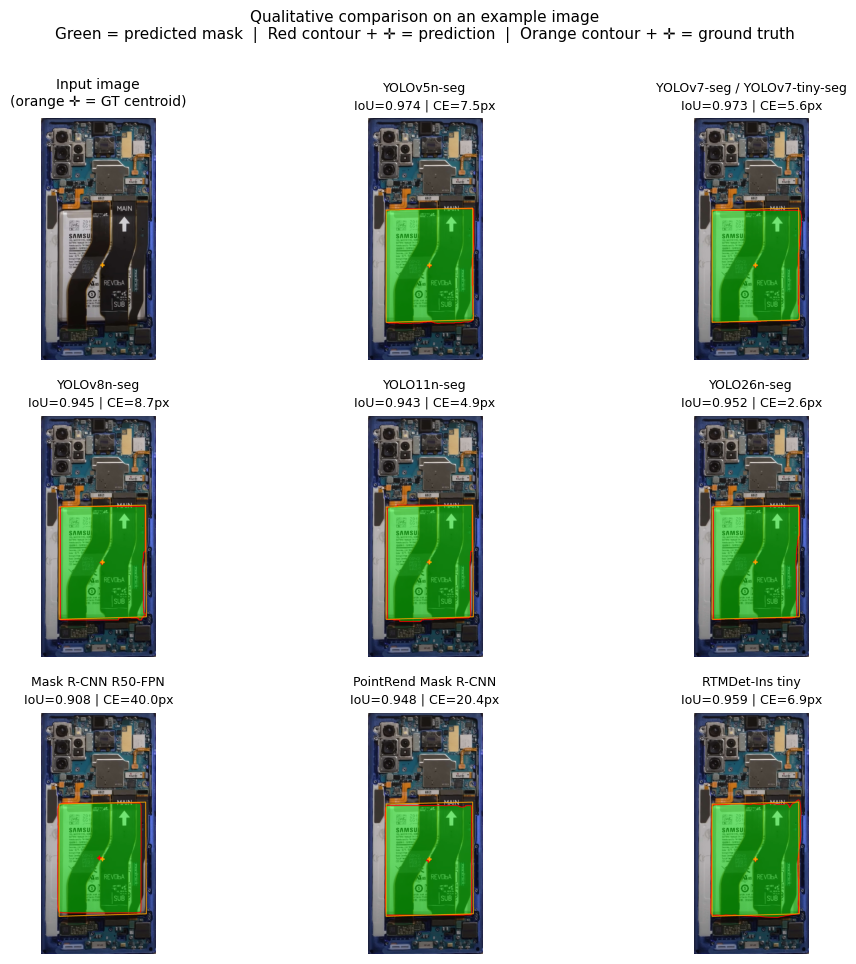

Saved: /content/drive/MyDrive/E-waste Battery Extraction CV/04_metrics_and_visualisations/qualitative_examples_8_models/qualitative_3x3_CamScanner_08-09-2025_06.15_111.png


In [86]:
# ── 18. 3 × 3 qualitative figure ──────────────────────────────────────────────
import matplotlib.pyplot as plt
def draw_centroid_marker(img, pt, color, marker_size=44, thickness=18, outline_size=52):
      x, y = int(pt[0]), int(pt[1])

      # Coloured marker on top
      cv2.drawMarker(
          img, (x, y),
          color=color,
          markerType=cv2.MARKER_CROSS,
          markerSize=marker_size,
          thickness=thickness
      )

def overlay(image_bgr, pred_mask, gt_mask, alpha=0.45):
    """Green overlay = prediction, red contour = pred boundary, orange = GT boundary."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).copy()
    if pred_mask is not None:
        ov = rgb.copy()
        ov[pred_mask.astype(bool)] = [0, 255, 0]
        rgb = cv2.addWeighted(ov, alpha, rgb, 1 - alpha, 0)
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    if pred_mask is not None:
        cnts, _ = cv2.findContours(pred_mask.astype(np.uint8),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(bgr, cnts, -1, (0, 0, 255), 10)        # red
    if gt_mask is not None:
        cnts, _ = cv2.findContours(gt_mask.astype(np.uint8),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(bgr, cnts, -1, (0, 165, 255), 10)      # orange

    # ── Centroid dots ─────────────────────────────────────────────────────────
    if pred_mask is not None:
        pc = mask_centroid(pred_mask)
        if pc is not None:
            draw_centroid_marker(bgr, pc, color=(0, 0, 255))      # red

    if gt_mask is not None:
        gc = mask_centroid(gt_mask)
        if gc is not None:
            cv2.drawMarker(bgr, (int(gc[0]), int(gc[1])),
                          color=(0, 165, 255),         # orange = ground truth
                          markerType=cv2.MARKER_CROSS,
                          markerSize=40, thickness=18)
    # ─────────────────────────────────────────────────────────────────────────

    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

# Panel order: [input] + 8 models → 9 panels → 3×3
PANEL_ORDER = [
    "Input image",
    "YOLOv5n-seg",
    "YOLOv7-seg / YOLOv7-tiny-seg",
    "YOLOv8n-seg",
    "YOLO11n-seg",
    "YOLO26n-seg",
    "Mask R-CNN R50-FPN",
    "PointRend Mask R-CNN",
    "RTMDet-Ins tiny",
]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for ax, name in zip(axes, PANEL_ORDER):
    ax.axis("off")
    if name == "Input image":
        # Show GT centroid on the input panel for reference
        img_rgb = cv2.cvtColor(QUAL_IMAGE, cv2.COLOR_BGR2RGB).copy()
        bgr_tmp = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        gc = mask_centroid(GT_MASK)
        if gc is not None:
            cv2.drawMarker(bgr_tmp, (int(gc[0]), int(gc[1])),
                           color=(0, 165, 255),
                           markerType=cv2.MARKER_CROSS,
                           markerSize=40, thickness=18)
        ax.imshow(cv2.cvtColor(bgr_tmp, cv2.COLOR_BGR2RGB))
        ax.set_title("Input image\n(orange ✛ = GT centroid)",
                     fontsize=10, pad=10)
        continue

    pred = qual_masks.get(name)
    if pred is None:
        ax.imshow(cv2.cvtColor(QUAL_IMAGE, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name}\n[prediction missing]", fontsize=11, pad=8, color="red")
        continue

    iou    = mask_iou(pred, GT_MASK)
    ce     = centroid_error_px(pred, GT_MASK)
    ce_str = f"{ce:.1f}px" if not np.isnan(ce) else "NaN"

    ax.imshow(overlay(QUAL_IMAGE, pred, GT_MASK))
    ax.set_title(f"{name}\nIoU={iou:.3f} | CE={ce_str}",
                 fontsize=9, pad=7, linespacing=1.5)

fig.suptitle(
    f"Qualitative comparison on an example image\n"
    "Green = predicted mask  |  Red contour + ✛ = prediction  |  Orange contour + ✛ = ground truth",
    fontsize=11, y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.955])
plt.subplots_adjust(hspace=0.23, wspace=0.03)

fig_path = QUAL_OUT / f"qualitative_3x3_{QUAL_IMAGE_PATH.stem}.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)